# Lab 10: Infection trees and heterogeneity

**How you will be graded**

This activity is out of 10 points. You will be graded on three things: completion, clear documentation, and correctness of your process.

* *Completion (4pts)*: This is solely whether you attempted and completed all portions of the computational assignment.
* *Documentation (4pts)*: Write comments above your code, describing what it does to demonstrate that you understand what the code is doing.
* *Correctness (2pts)*: Does your code run and produce the correct output?

# Playground!

In this section you will be given a set of tasks to complete on your own, and you will have to figure out how to do them using the resources provided (videos, documentation, etc). This way you can learn at your own pace and also get used to looking up documentation and learning how to use new tools on your own.

The very first task is to import the required packages, in this lab we will analyze infection trees. To do that we will use `numpy`, `matplotlib.pyplot`, `polars`, and `networkx`

Try importing the required libraries below (dont forget you can use the `as` keyword to give them a shorter alias):


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import networkx as nx

In [33]:
def hierarchy_pos(G, root=None, width=1., vert_gap = 0.2, vert_loc = 0, xcenter = 0.5):

    '''
    From Joel's answer at https://stackoverflow.com/a/29597209/2966723.  
    Licensed under Creative Commons Attribution-Share Alike 
    
    If the graph is a tree this will return the positions to plot this in a 
    hierarchical layout.
    
    G: the graph (must be a tree)
    
    root: the root node of current branch 
    - if the tree is directed and this is not given, 
      the root will be found and used
    - if the tree is directed and this is given, then 
      the positions will be just for the descendants of this node.
    - if the tree is undirected and not given, 
      then a random choice will be used.
    
    width: horizontal space allocated for this branch - avoids overlap with other branches
    
    vert_gap: gap between levels of hierarchy
    
    vert_loc: vertical location of root
    
    xcenter: horizontal location of root
    '''
    if not nx.is_tree(G):
        raise TypeError('cannot use hierarchy_pos on a graph that is not a tree')

    if root is None:
        if isinstance(G, nx.DiGraph):
            root = next(iter(nx.topological_sort(G)))  #allows back compatibility with nx version 1.11
        else:
            root = random.choice(list(G.nodes))

    def _hierarchy_pos(G, root, width=1., vert_gap = 0.2, vert_loc = 0, xcenter = 0.5, pos = None, parent = None):
        '''
        see hierarchy_pos docstring for most arguments

        pos: a dict saying where all nodes go if they have been assigned
        parent: parent of this branch. - only affects it if non-directed

        '''
    
        if pos is None:
            pos = {root:(xcenter,vert_loc)}
        else:
            pos[root] = (xcenter, vert_loc)
        children = list(G.neighbors(root))
        if not isinstance(G, nx.DiGraph) and parent is not None:
            children.remove(parent)  
        if len(children)!=0:
            dx = width/len(children) 
            nextx = xcenter - width/2 - dx/2
            for child in children:
                nextx += dx
                pos = _hierarchy_pos(G,child, width = dx, vert_gap = vert_gap, 
                                    vert_loc = vert_loc-vert_gap, xcenter=nextx,
                                    pos=pos, parent = root)
        return pos

            
    return _hierarchy_pos(G, root, width, vert_gap, vert_loc, xcenter)

# 1. Importing data
For this lab we will work with this huge dataset of transmission trees by Taube et al ([LINK](https://doi.org/10.1371/journal.pbio.3001685)). Below is some text from the paper's abstract explaining the dataset.

"We compiled a database, called OutbreakTrees, of 382 published, standardized transmission trees consisting of 16 directly transmitted diseases ranging in size from 2 to 286 cases. For each tree and disease, we calculated several key statistics, such as tree size, average number of secondary infections, the dispersion parameter, and the proportion of cases considered superspreaders, and examined how these statistics varied over the course of each outbreak and under different assumptions about the completeness of outbreak investigations."

We will utilize a few of these trees to first calculate some metrics about the outbreak in question and then finally simulate a SIR model using those metrics.

The very first step is to load the data, we have two files for our data, one for the edges and one for the nodes. Each file has a column called ID used to identify the network our node/edge is a part of.

For this step we have provided the code to load the data into a dictionary called `trees`. Your job is to try and understand how we do this and comment the code.


In [34]:
df_edges = pl.read_csv("../data/outbreak-trees/edgelist.csv")
df_nodes = pl.read_csv("../data/outbreak-trees/nodelist.csv")
tree_names = df_nodes["id"].unique().to_list()
trees = {}
for t in tree_names:
    G = nx.DiGraph()
    G.add_nodes_from(df_nodes.filter(df_nodes["id"] == t)["name"].to_list())
    edges = df_edges.filter(df_edges["id"] == t)
    G.add_edges_from(zip(edges["from"].to_list(), edges["to"].to_list()))
    G.name = t
    trees[t] = G
print(trees)

{'chn.2018.adv.1.12': <networkx.classes.digraph.DiGraph object at 0x11f0df6d0>, 'hkg.2020.covid.1.57': <networkx.classes.digraph.DiGraph object at 0x11d307ed0>, 'kor.2020.covid.3.00': <networkx.classes.digraph.DiGraph object at 0x11d3e0050>, 'kor.2020.covid.1.00': <networkx.classes.digraph.DiGraph object at 0x11d374cd0>, 'aus.2010.meas.1.00': <networkx.classes.digraph.DiGraph object at 0x11d374c50>, 'hkg.2020.covid.1.49': <networkx.classes.digraph.DiGraph object at 0x11d374dd0>, 'gin.2014.ebv.1.05': <networkx.classes.digraph.DiGraph object at 0x11d3744d0>, 'gin.2014.ebv.2.00': <networkx.classes.digraph.DiGraph object at 0x11d375250>, 'bgd.2001.nph.1.12': <networkx.classes.digraph.DiGraph object at 0x11d3756d0>, 'hkg.2020.covid.1.11': <networkx.classes.digraph.DiGraph object at 0x11d3759d0>, 'deu.2020.covid.2.00': <networkx.classes.digraph.DiGraph object at 0x11d375dd0>, 'usa.2009.flu.1.00': <networkx.classes.digraph.DiGraph object at 0x11d376150>, 'jpn.2017.meas.1.00': <networkx.classe

# 2. Choosing our trees

For this analysis we will only look at two trees, so we can choose the two largest trees to analyze. We will use `np.argsort` to sort our trees based on how many edges each of them has and then take the two largest trees from the output list of indices.

Note: `np.argsort` sorts in ascending order by default, so we choose the two trees from the end of the resulting list. Also it gives us a list of indices of trees and not the trees itself. Use these indices to extract the tree name and then use that name to extract the network itself from the dictionary of trees.

**Extra Credit**: Use subplots to plot two side-by-side networks for 0.5 EC.

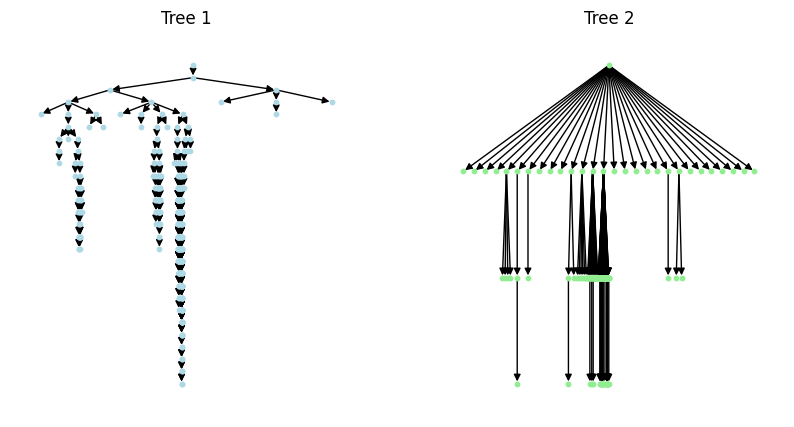

In [35]:
# TODO: Fill the blanks with correct variables
sorted_tree_id = np.argsort([trees[name].number_of_edges() for name in tree_names])

# TODO: Choose the two largest trees, tree_1 and tree_2 are graphs
tree_1 = trees[tree_names[sorted_tree_id[-1]]]
tree_2 = trees[tree_names[sorted_tree_id[-2]]]

# TODO: Draw the trees as well! (use both nx.draw)
fig, axes = plt.subplots(1, 2, figsize = (10, 5))

# First tree
nx.draw(tree_1, 
        node_size=10, 
        node_color="lightblue", 
        pos=hierarchy_pos(tree_1), 
        ax = axes[0])
axes[0].set_title(f"Tree 1")

# Second tree
nx.draw(tree_2, 
        node_size=10, 
        node_color="lightgreen", 
        pos=hierarchy_pos(tree_2), 
        ax = axes[1])
axes[1].set_title(f"Tree 2")

plt.show()

# 3. Finding $R_0$ and quantifying heterogeneity
### 3.1 $R_0$
The most basic and popular metric people use to define epidemics is $R_0$. It is the basic reproduction number for an epidemic and its value can describes the initial contagiousness of an infectious disease. It represents the average number of new infections caused by one infected person in a completely susceptible population, in the absence of any public health interventions or prior immunity. 

$R_0$ tells us if the epidemic will spread, stabilize or die off:
*   If $R_0 < 1$, the disease will eventually decline and die out because each existing infection causes, on average, less than one new infection.
*   If $R_0 = 1$, the disease will remain stable within the population, with each case leading to approximately one new case.
*   If $R_0 > 1$, the disease has the potential to spread and cause an outbreak or epidemic.

We can calculate the $R_0$ of an infection tree as the average number of infections caused by each individual (node). So for a `nx.DiGraph()` it becomes the average out degree for the network.

Calculate and print $R_0$ for our two graphs.

Note: `[G.out_degree(n) for n in G.nodes]` gives us a list of out-degrees for each node. Use this to find the average out degree of our two networks, here G is replaced with the name of your graph. 

In [36]:
# TODO: Find the average out degree
out_deg_1_vals = [out_degree for node, out_degree in tree_1.out_degree()]
R0_1 = np.mean(out_deg_1_vals)

# TODO: Do the same thing for tree_2
out_deg_2_vals = [out_degree for node, out_degree in tree_2.out_degree()]
R0_2 = np.mean(out_deg_2_vals)

print(f"{round(10 * R0_1, 2)}% and {round(10 * R0_2, 2)}%")

9.97% and 9.95%


What were the $R_0$ values for our trees? What does that mean?

The values were 9.97% and 9.95% which describes how contagious the disease in `tree_1` and `tree_2` are.

### 3.2 Heterogeneity

Is $R_0$ a complete measure? Turns out it is not! Heterogeneity, or individual variation in susceptibility, infectiousness, and contact patterns, plays a crucial role in disease transmission dynamics and significantly affects the interpretation and estimation of $R_0$. Traditional simple $R_0$ models often assume a well-mixed, homogeneous population, which is rarely the case in reality.

To better understand and predict epidemic dynamics, epidemiologists look beyond a single $R_0$ value and consider the full distribution of secondary infections. Which in our case becomes the out-degree distribution!

Lets plot bar graphs for our out-degrees!

**Extra Credit**: Use subplots to plot two side-by-side plots for 0.5 EC.

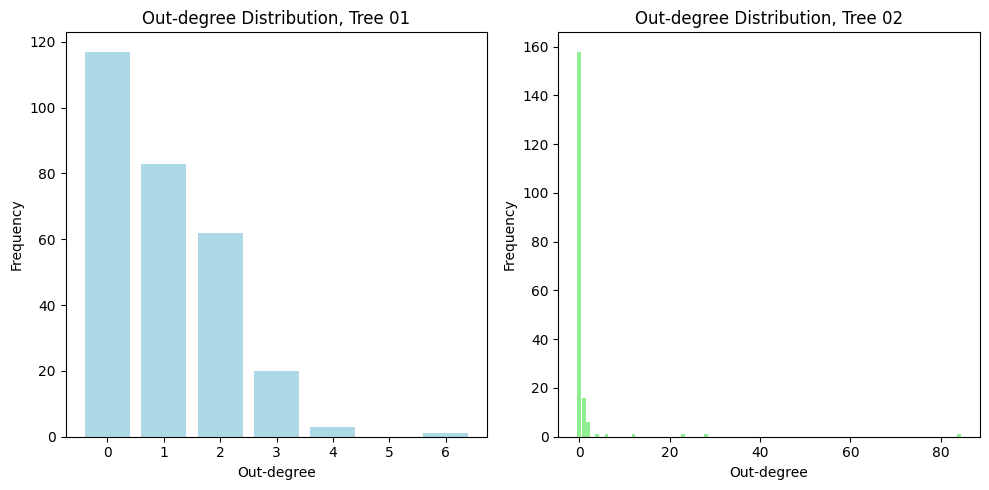

In [37]:
# TODO: Plotting for tree 1
degrees_ls_1 = sorted([d for n, d in tree_1.out_degree()])
deg_1, freq_1 = np.unique(degrees_ls_1, return_counts=True)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot Tree 1 distribution
axes[0].bar(deg_1, freq_1, color="lightblue")
axes[0].set_xlabel("Out-degree")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Out-degree Distribution, Tree 01")

# Plot Tree 2 distribution
axes[1].bar(deg_2, freq_2, color="lightgreen")
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Out-degree Distribution, Tree 02")

plt.tight_layout()
plt.show()

Do you notice anything from these plots? What can you say about the epidemic from these plots?

The first tree shows that most people infected only a few others, meaning the disease spread slowly and evenly. The second tree shows that a few people infected many others, while most infected none. This means the outbreak was uneven, a few “super-spreaders” caused most of the spread.

### 3.2 Quantifying heterogeneity

These plots show us something important, they tell us that there is heterogeneity in our spreaders. But they dont tell us how much heterogeneity there is, remember that $R_0$ told us on average how many secondary infections each infected individual causes. So, any large deviation from that would either mean you dont cause a lot of infections OR you cause a lot of infections, making you a super spreader!

So, to quantify this heterogeneity and see if the epidemic is spreading uniformly or due to super-spreaders, we can find the variance (or standard deviation) of the degree distribution. Remember the mean of our degree distribution was $R_0$ so its variance tells us how much our individuals deviate from that mean.

NOTE: You can use `np.std` to find the standard deviation and then normalize it using the mean of our distribution. This gives us the coefficient of variation, CV > 1 means high variance and CV < 1 means low variance.

In [38]:
# TODO: Use np.std and np.mean to find the CV of tree 1 and tree 2
CV_1 = np.std(degrees_ls_1) / np.mean(degrees_ls_1)
CV_2 = np.std(degrees_ls_2) / np.mean(degrees_ls_2)

# TODO: Print these values
print("Coefficient of Variation (Tree 1):", CV_1)
print("Coefficient of Variation (Tree 2):", CV_2)

Coefficient of Variation (Tree 1): 1.0464438012223358
Coefficient of Variation (Tree 2): 6.764978781258952


Explain what these values tell us about the networks of our choice? How can $R_0$ be misleading if our CV is high?

Tree 1’s CV is close to 1, meaning most nodes spread the infection to about the same number of others, the outbreak there is fairly uniform. Tree 2’s CV is very high (around 6.76), showing huge variation: a few nodes infect many people while most infect few or none. This tells us the second network is dominated by super-spreaders.

When CV is high, $R_0$ can be misleading, because the “average” hides that most people infect almost no one while a few drive nearly all the spread. In other words, a high $R_0$ might make it seem like everyone is equally infectious, when in reality the epidemic depends on a small number of highly connected individuals.

# 4. Lets make our own infection trees!

In this section we will use the stochastic model from Lab 9 (with some modifications) to create our own infection trees!

This is still a simple SI model, but whenever a node gets infected we add an edge between the nodes in an empty `nx.DiGraph()`.

Since there are some modifications, this section will be a FITB.

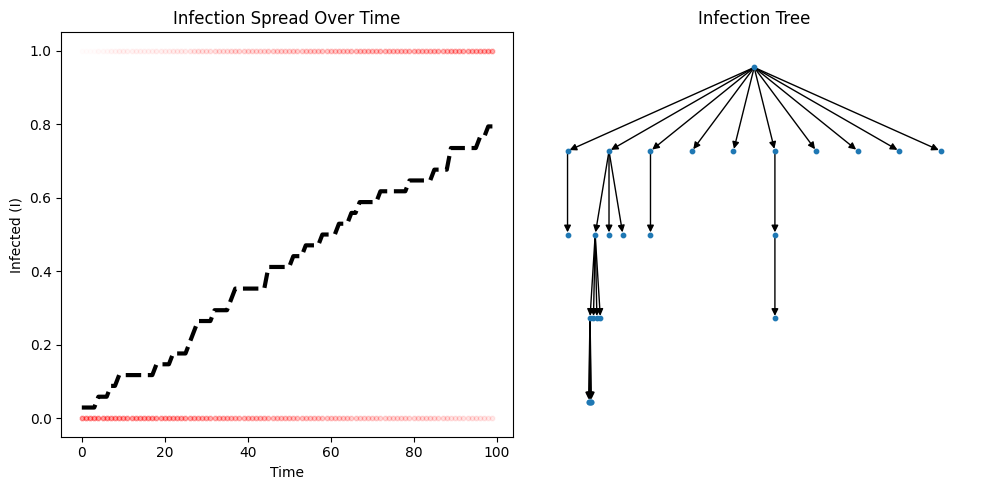

In [39]:
T = 100
G = nx.karate_club_graph()
A = nx.to_numpy_array(G)

G_tree = nx.DiGraph()

# TODO: Define the necessary parameters
beta = 0.01  # infection probability per contact

# TODO: Initialize your S0 and I0
S0 = np.ones(G.number_of_nodes())
I0 = np.zeros(G.number_of_nodes())
I0[0] = 1  # start infection with one node

# TODO: Create lists to store them
S = [S0]
I = [I0]

for t in range(T - 1):
    # TODO: Define I_new
    I_new = np.zeros(G.number_of_nodes())

    # Loop over all nodes to update infection
    for i in range(G.number_of_nodes()):
        if I[t][i] == 0:
            for j in G.neighbors(i):
                if I[t][j] == 1:
                    if np.random.rand() < beta:
                        I_new[i] = 1
                        G_tree.add_edge(j, i)
                        break
        else:
            I_new[i] = 1

    # TODO: Append the new arrays to S and I
    S.append(1 - I_new)
    I.append(I_new)

# Changed plotting to use subplots.
fig, axes = plt.subplots(1, 2, figsize=(10, 5)) # Axes

# Same-ish, left infection over time
for i in range(T):
    axes[0].scatter(i * np.ones(I[i].shape), I[i], color="red", s=10, alpha=0.01)
axes[0].plot(range(T), [j.mean() for j in I], "k--", linewidth=3)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Infected (I)")
axes[0].set_title("Infection Spread Over Time")

# Right, infection tree
nx.draw(G_tree, node_size=10, pos=hierarchy_pos(G_tree), ax=axes[1])
axes[1].set_title("Infection Tree")

plt.tight_layout()
plt.show()



# Extra credit - 2 points
Mathematically, $R_0 = \dfrac{\beta}{\gamma} S_0$, so essentially the number of susceptibles that get infected divided by how many infected get recovered. Using the intial value of our susceptible population we can estimate different combinations of $\beta$ and $\gamma$ to match our infection tree's $R_0$.

For this excercise, we will use the well-mixed SIR model to simulate how our infection tree epidemic would have spread in a homogenous population. Does it even end up spreading or do we see the epidemic die out sooner than expected? Assume we have $\beta = 0.05$, calculate the corresponding $\gamma$ using your trees $R_0$ and population $S_0$ values. Create a well mixed SIR model with these parameters and plot the frequency changes in S, I and R compartments.

NOTE: You will have to write the equations for each compartment before you move formward with the code. Please refer to previous lab on how to form the equations, look into the extra credit with the SIS model, the only difference here will be that your infected will go into a new compartment called the `recovered` compartement (R) instead of back into S as they recover from the disease.

I can look back to `lab-09` and get information about the well-mixed SIR model.

We model disease spread using three compartments: $S(t)$, susceptible. $I(t)$, infected. $R(t)$, recovered. Each individual moves through these states over time according to the infection rate $\beta$ and recovery rate $\gamma$.  


$$
\frac{dS}{dt} = -\beta S I, \quad 
\frac{dI}{dt} = \beta S I - \gamma I, \quad 
\frac{dR}{dt} = \gamma I
$$

The **basic reproduction number** is  

$$
R_0 = \frac{\beta S_0}{\gamma}
$$

which describes how many new infections one case causes on average.  
Rearranging gives  

$$
\gamma = \frac{\beta S_0}{R_0}
$$

Simulate this using the previously defined **Euler’s method**, updating each compartment at small time steps $\Delta t$:  

$$
S_{t+\Delta t} = S_t - \Delta t\,\beta S_t I_t
$$
$$
I_{t+\Delta t} = I_t + \Delta t(\beta S_t I_t - \gamma I_t)
$$
$$
R_{t+\Delta t} = R_t + \Delta t\,\gamma I_t
$$

This explanation is inspired from `lab-09`.

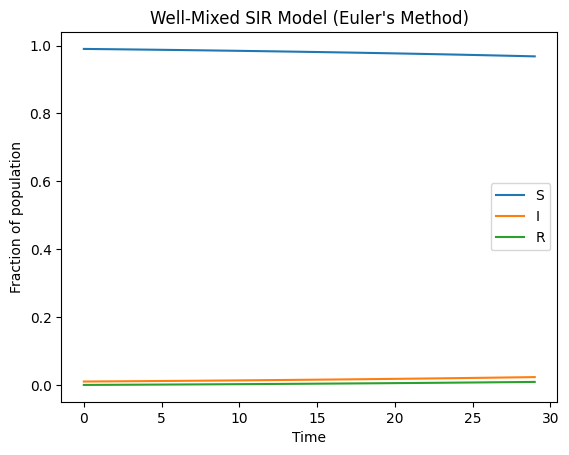

In [40]:
# Euler's method for SIR models, lot of which is copied from `lab-09`. 

# TODO: Fill in values for our parameters
beta = 0.05  # Probability of infection spread (<1)
R0 = 2.5     # From infection tree
S0 = 0.99    # Initial susceptible fraction
I0 = 0.01    # Initial infected fraction
R_init = 0.0 # Initial recovered fraction

# Calculate gamma from R0 formula
gamma = beta * S0 / R0
T = 30  # Duration of simulation

# TODO: Define initial lists to store frequencies
S = [S0]
I = [I0]
R = [R_init]

# TODO: Create a loop to run (T-1) times
for t in range(T - 1):
    # TODO: How will S, I, and R change at each time step?
    S_change = -beta * S[t] * I[t]
    I_change = beta * S[t] * I[t] - gamma * I[t]
    R_change = gamma * I[t]

    # Compute new values using Euler's method
    S_new = S[t] + S_change
    I_new = I[t] + I_change
    R_new = R[t] + R_change

    # Append new values to the lists
    S.append(S_new)
    I.append(I_new)
    R.append(R_new)

# Plot S, I, and R wrt T
plt.plot(range(T), S, label="S")
plt.plot(range(T), I, label="I")
plt.plot(range(T), R, label="R")

plt.xlabel("Time")
plt.ylabel("Fraction of population")
plt.legend()
plt.title("Well-Mixed SIR Model (Euler's Method)")
plt.show()

